# Run adaptive immune system with noisy pMHCs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from sklearn.feature_selection import mutual_info_classif
from stoch_sim_model import *

plt.style.use('/Users/ObinnaUkogu/Desktop/custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

### (1) Plot sample trajectory

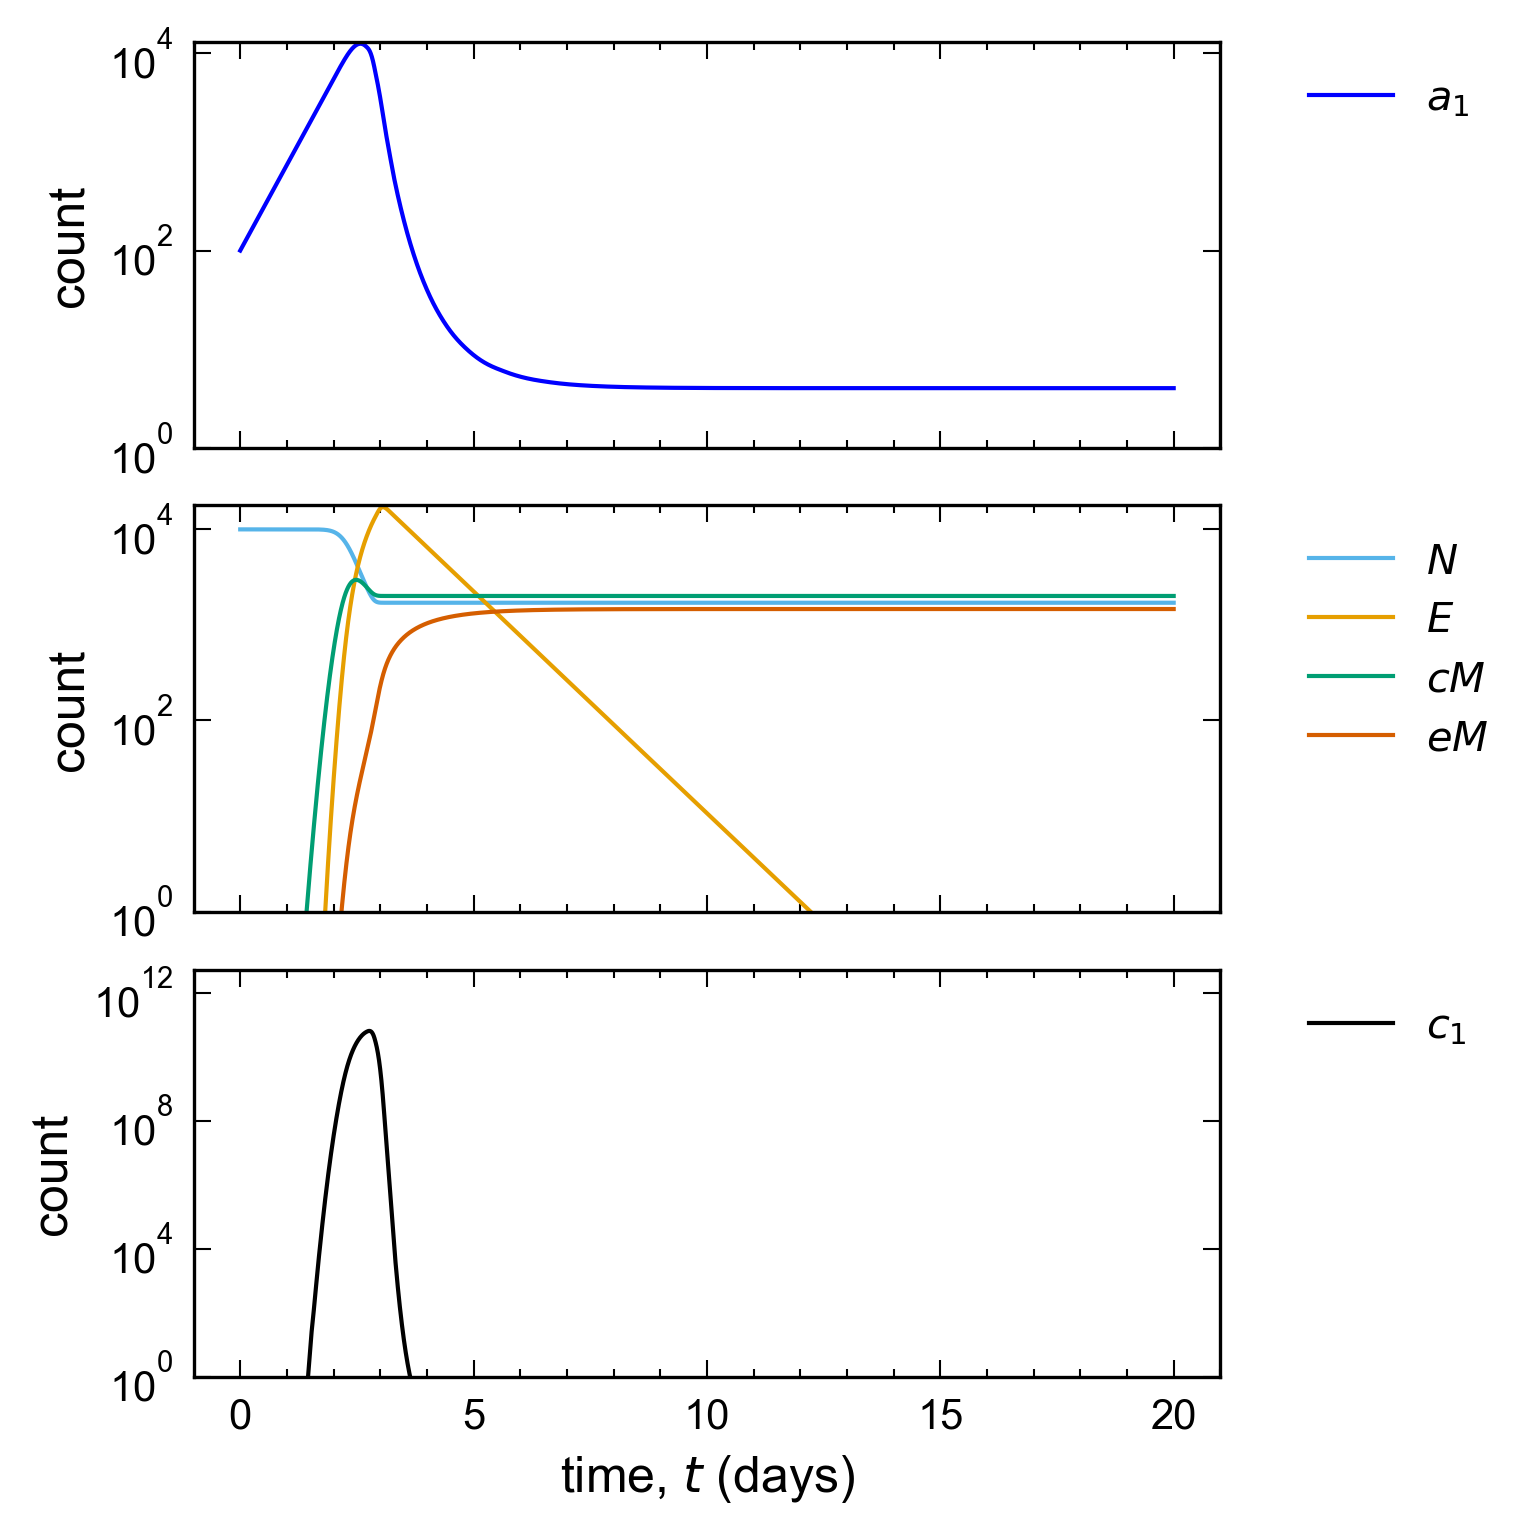

In [2]:
# Plot outputs
a1_0 = 100
b_a1 = 2
t1 = 10
d_a1 = 3.8*10**(-4)
T_a1 = 10

a1, N, E, cM, eM, T, ts = stoch_sim(a1_0, b_a1, t1, d_a1, noise_model = "pop", noise_cv = [0.0, 0.0, 0.0])
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = True, figsize=(5,5))
#ax1.plot(ts, a1/a2, 'b', label = r'$\frac{a_1}{a_2}$')
ax1.plot(ts, a1, 'b', label = r'$a_1$')
ax1.set(ylabel='count')
ax1.set_ylim(1,)
ax1.semilogy()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, N, label = r'$N$')
ax2.plot(ts, E, label = r'$E$')
ax2.plot(ts, cM, label = r'$cM$')
ax2.plot(ts, eM, label = r'$eM$')
ax2.set(ylabel='count')
ax2.set_ylim(1,)
ax2.semilogy()
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(ts, c1_ss.py_func(t1,a1, E, T),'k-', label = r'$c_1$')
#ax3.plot(ts, c1_ss(P1.py_func(a1, E)[0], E, T)/k_E,'k-', label = r'$\frac{c_1}{k_E}$')
#ax3.plot(ts, c2_ss(a1,E),'k-.', label = r'$c_2$')
ax3.set(xlabel=r'time, $t$ (days)', ylabel='count')
ax3.semilogy()
ax3.set_ylim(1,)
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

fig.savefig('virus-effector dynamics.pdf', dpi=300)

## (2) Parallelize simulation runs

In [3]:
# Parallelize simulation runs

def for_parallel(a1_0, b_a1, t1, d_a1, noise_cv = [0.05,0.0,0.0]):
    
    return sum_sim(a1_0, b_a1, t1, d_a1, noise_cv = noise_cv)

In [4]:
# Set global simulation parameters
runs = 10000

In [5]:
# run several simulations varying b_a1
#b_a1s = np.random.uniform(0.1*b_a1, 10*b_a1, size = runs) 
b_a1s = np.random.lognormal(mean = np.log(b_a1), sigma = 0.5*np.log(b_a1), size = runs)
t1s = [t1]
d_a1s = [d_a1]
T_a1s = [T_a1]
a1_0s = [a1_0]

run_data_b_a1 = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(b_a1s)/8))(delayed(for_parallel)(a1_0, b_a1, t1, d_a1)
                                              for a1_0 in a1_0s
                                              for b_a1 in b_a1s
                                              for t1 in t1s
                                              for d_a1 in d_a1s))

In [6]:
# run several simulations varying t1
b_a1s = [b_a1] #np.abs(np.random.normal(loc = mu_b_a1, scale = mu_b_a1, size = runs))
t1s = np.random.uniform(t1, 2*t1, size = runs) 
#t1s = np.random.lognormal(mean = np.log(t1), sigma = 0.1*np.log(t1), size = runs)
d_a1s = [d_a1]
T_a1s = [T_a1]
a1_0s = [a1_0]

run_data_t1 = np.nan_to_num(np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(t1s)/8))(delayed(for_parallel)(a1_0, b_a1, t1, d_a1)
                                              for a1_0 in a1_0s                                                  
                                              for b_a1 in b_a1s
                                              for t1 in t1s
                                              for d_a1 in d_a1s)))

In [7]:
# run several simulations varying d_a1
b_a1s = [b_a1] #np.abs(np.random.normal(loc = mu_b_a1, scale = mu_b_a1, size = runs))
#d_a1s = np.random.uniform(0.1*d_a1, 10*d_a1, size = runs) 
t1s = [t1]
d_a1s = np.random.lognormal(mean = np.log(d_a1), sigma = 1, size = runs)
T_a1s = [T_a1]
a1_0s = [a1_0]

run_data_d_a1 = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(d_a1s)/8))(delayed(for_parallel)(a1_0, b_a1, t1, d_a1)
                                              for a1_0 in a1_0s
                                              for b_a1 in b_a1s
                                              for t1 in t1s
                                              for d_a1 in d_a1s))

In [8]:
# run several simulations varying a1_0
b_a1s = [b_a1]
T_a1s = [T_a1]
#a1_0s = np.random.uniform(a1_0, 100*a1_0, size = runs) 
t1s = [t1]
d_a1s = [d_a1]
a1_0s = np.random.lognormal(mean = np.log(a1_0), sigma = 0.5*np.log(a1_0), size = runs)

run_data_a1_0 = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(a1_0s)/8))(delayed(for_parallel)(a1_0, b_a1, t1, d_a1)
                                              for a1_0 in a1_0s
                                              for b_a1 in b_a1s
                                              for t1 in t1s
                                              for d_a1 in d_a1s))

## (3) Plot distribution of response statistics from simulations varying $b_{a_1}$ and $t_1$

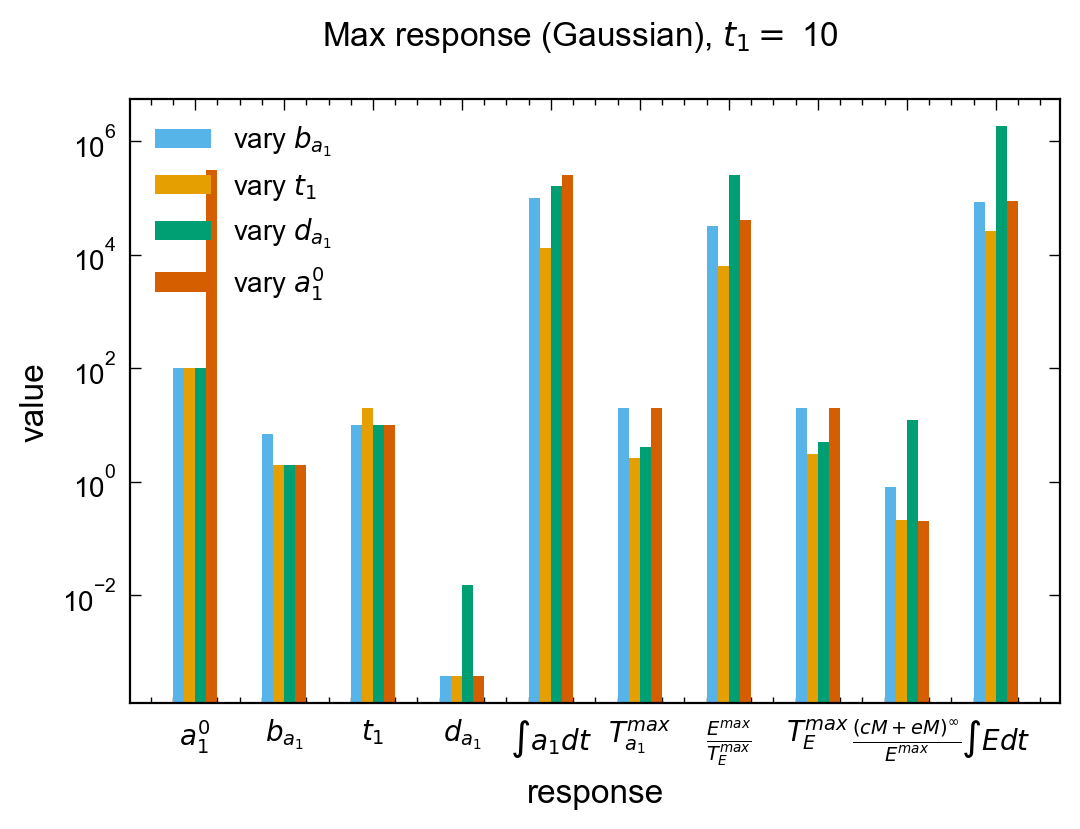

In [9]:
# Compute max values in the data
r = 2*np.arange(len(stat_names))
width = 0.25
plt.bar(r, np.amax(run_data_b_a1, axis = 0), width = width, label = r'vary $b_{a_1}$')
plt.bar(r + width, np.amax(run_data_t1, axis = 0), width = width, label = r'vary $t_1$')
plt.bar(r + 2*width, np.amax(run_data_d_a1, axis = 0), width = width, label = r'vary $d_{a_1}$')
plt.bar(r + 3*width, np.amax(run_data_a1_0, axis = 0), width = width, label = r'vary $a_{1}^0$')

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r + 3*width/2,stat_names)

plt.semilogy()
plt.legend()
plt.suptitle(r'Max response (Gaussian), $t_1=$ '+str(t1))
plt.savefig('response-max-gauss-t1-'+str(t1)+'.png', dpi=150)

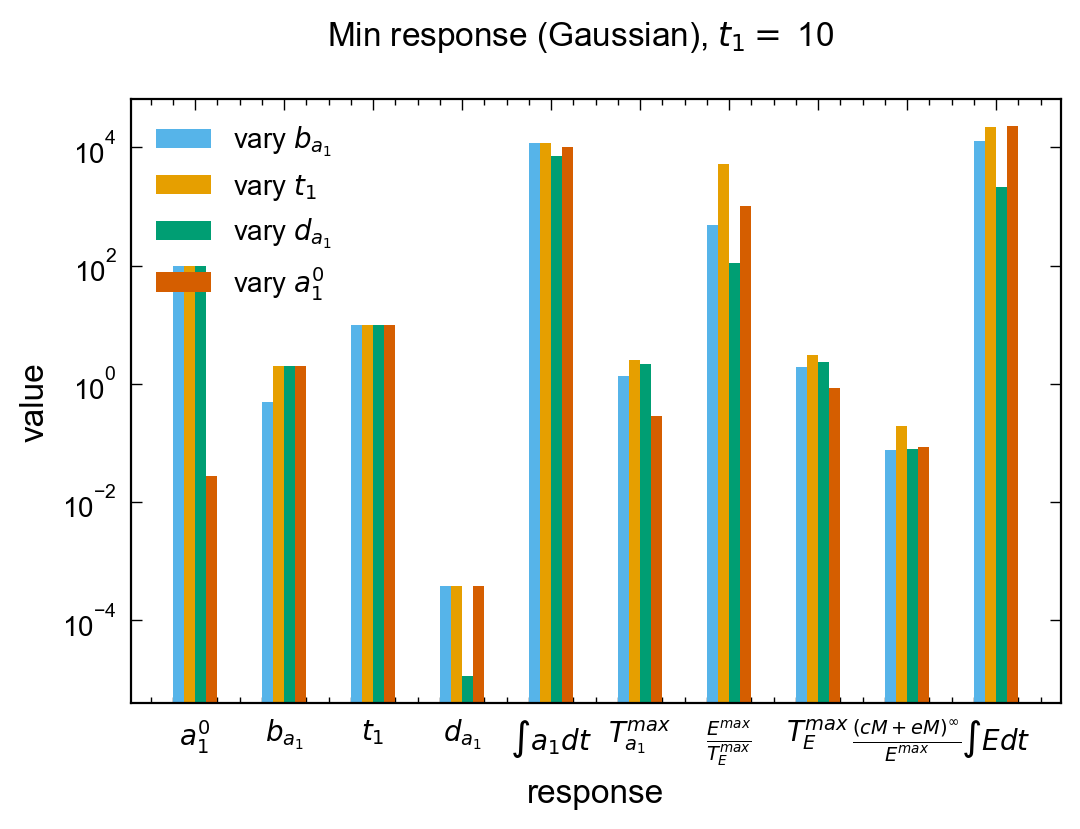

In [10]:
# Compute minimum values in the data
r = 2*np.arange(len(stat_names))
width = 0.25
plt.bar(r, np.amin(run_data_b_a1, axis = 0), width = width, label = r'vary $b_{a_1}$')
plt.bar(r + width, np.amin(run_data_t1, axis = 0), width = width, label = r'vary $t_1$')
plt.bar(r + 2*width, np.amin(run_data_d_a1, axis = 0), width = width, label = r'vary $d_{a_1}$')
plt.bar(r + 3*width, np.amin(run_data_a1_0, axis = 0), width = width, label = r'vary $a_{1}^0$')

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r + 3*width/2,stat_names)

plt.semilogy()
plt.legend()
plt.suptitle(r'Min response (Gaussian), $t_1=$ '+str(t1))
plt.savefig('response-min-gauss-t1-'+str(t1)+'.png', dpi=150)

## (4) Compute mutual information between variables

In [11]:
# compute mutual information
MI_a1_0 = np.zeros(run_data_a1_0.shape[1])
for i in range(run_data_a1_0.shape[1]):
    MI_a1_0[i] = calc_MI(run_data_a1_0[:,0],run_data_a1_0[:,i])  

MI_b_a1 = np.zeros(run_data_b_a1.shape[1])
for i in range(run_data_b_a1.shape[1]):
    MI_b_a1[i] = calc_MI(run_data_b_a1[:,1],run_data_b_a1[:,i])

MI_t1 = np.zeros(run_data_t1.shape[1])
for i in range(run_data_t1.shape[1]):
    MI_t1[i] = calc_MI(run_data_t1[:,2],run_data_t1[:,i])
    
MI_d_a1 = np.zeros(run_data_d_a1.shape[1])
for i in range(run_data_d_a1.shape[1]):
    MI_d_a1[i] = calc_MI(run_data_d_a1[:,3],run_data_d_a1[:,i])

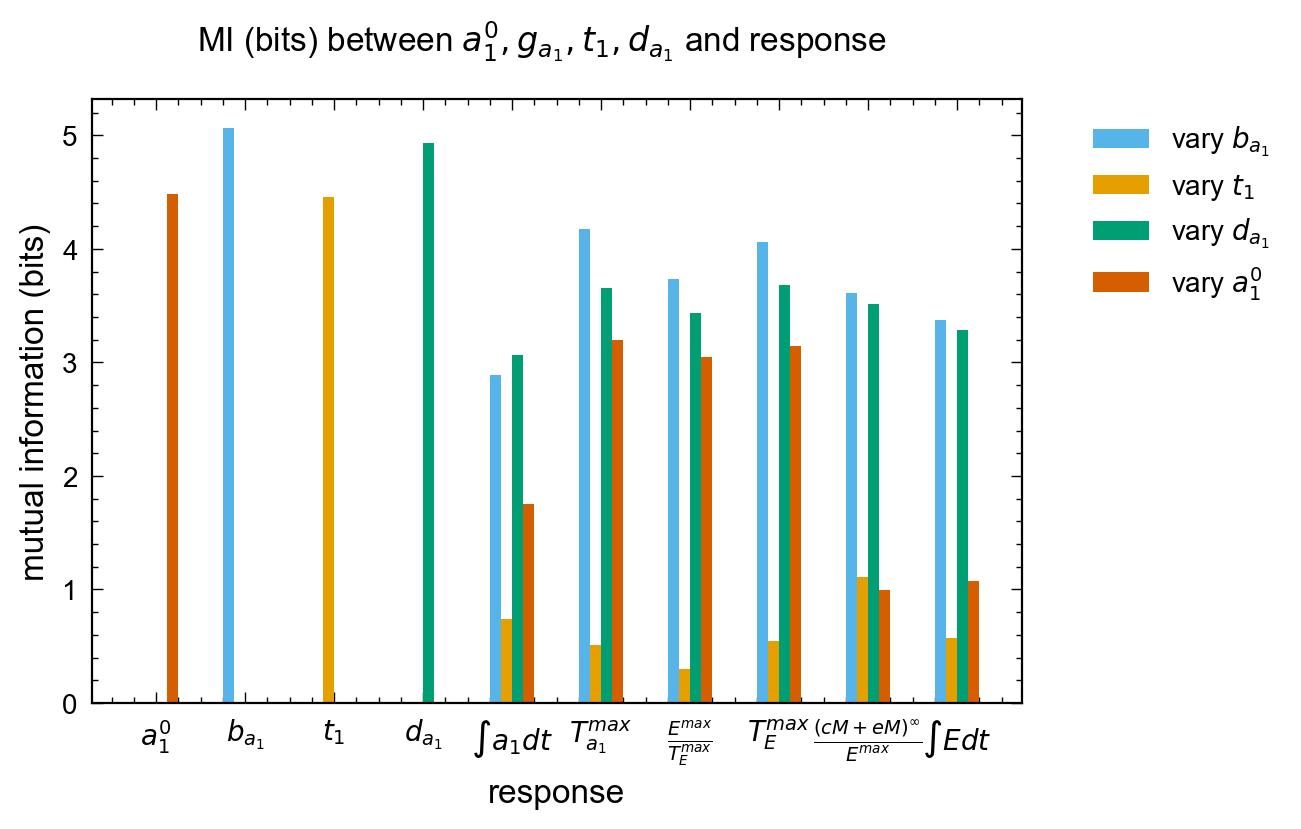

In [17]:
# Plot mutual information
plt.figure(1)

r = 2*np.arange(len(MI_b_a1))
width = 0.25
plt.bar(r, MI_b_a1, width = width, label = r'vary $b_{a_1}$')
plt.bar(r + width, MI_t1, width = width, label = r'vary $t_1$')
plt.bar(r + 2*width, MI_d_a1, width = width, label = r'vary $d_{a_1}$')
plt.bar(r + 3*width, MI_a1_0, width = width, label = r'vary $a_{1}^0$')

plt.xlabel("response")
plt.ylabel("mutual information (bits)")

plt.xticks(r + 3*width/2,stat_names)
#plt.legend()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.suptitle(r'MI (bits) between $a_1^0, g_{a_1}, t_1, d_{a_1}$ and response')
plt.savefig('response-mutual-info-gauss-t1-'+str(t1)+'.png', dpi=150)

## (5) Plot trajectories from simulations

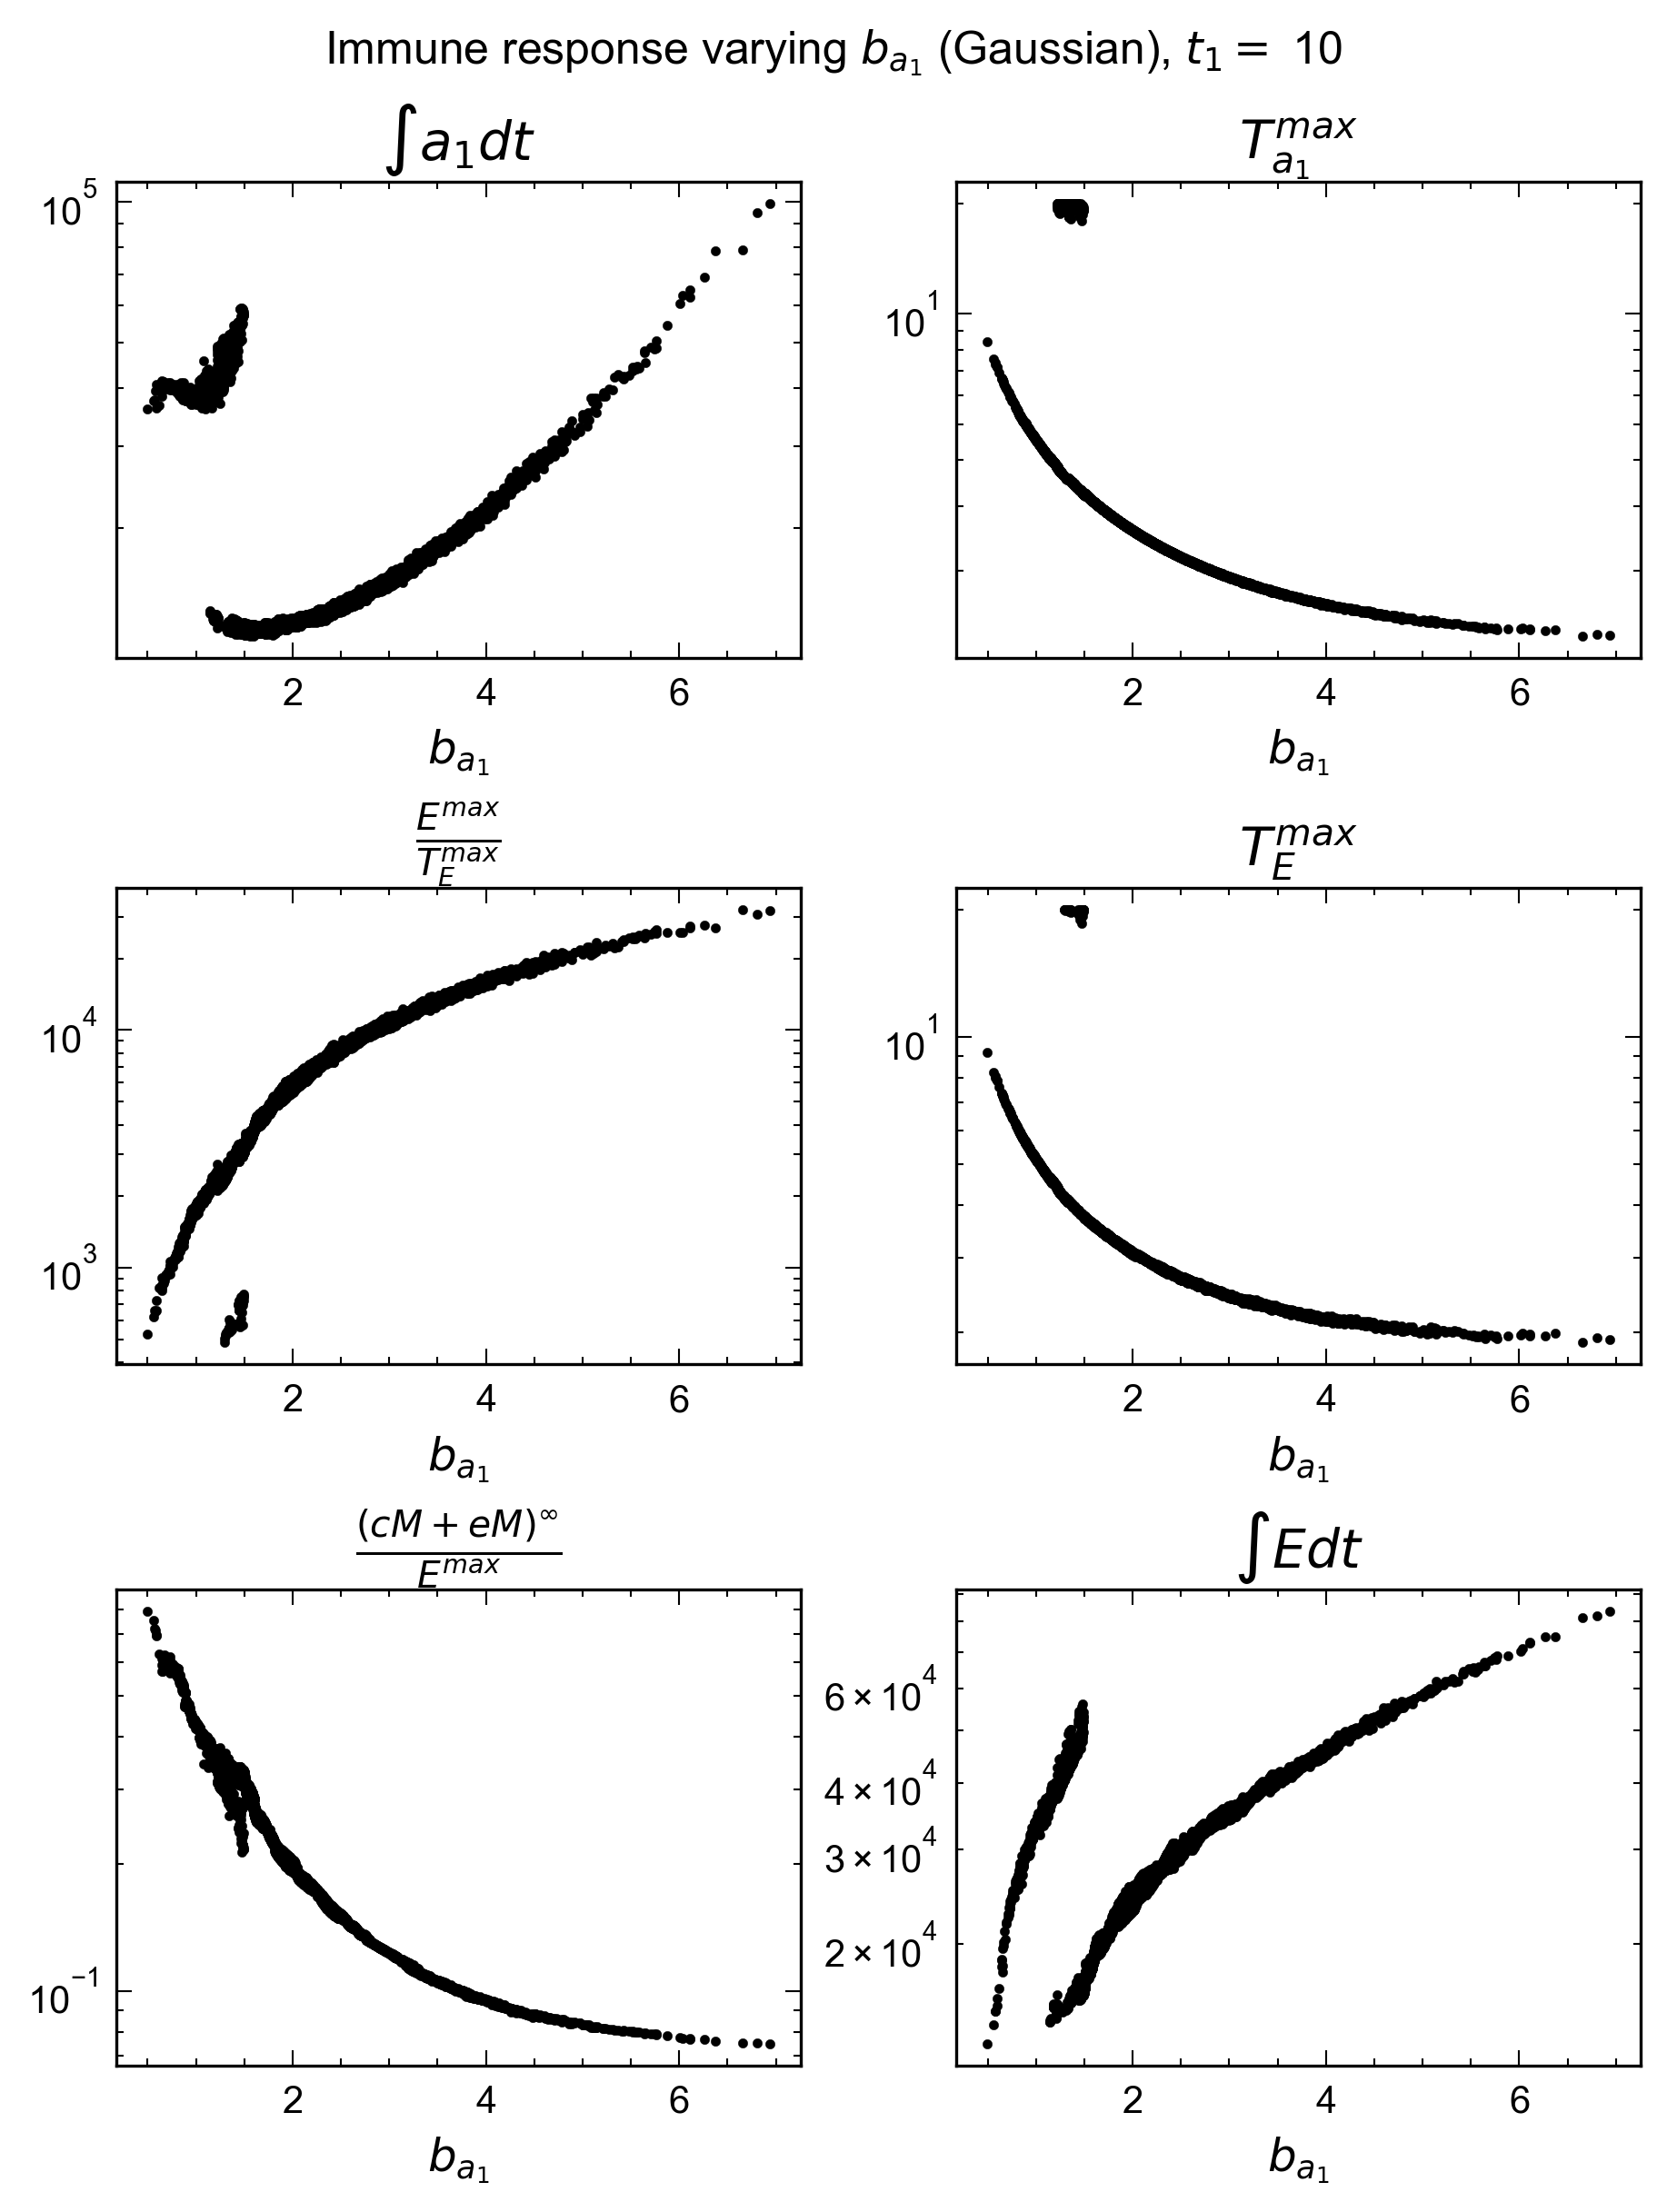

In [13]:
# Plot trajectories for b_a1
fig_b_a1, axs = plt.subplots(3, 2, dpi = 150, constrained_layout=True, figsize=(6,8))
i = 4
for ax, val in zip(axs.flat,stat_names[i:]):

    cs = ax.plot(run_data_b_a1[:,1],run_data_b_a1[:,i],'k.')
    ax.set_title(val)
    ax.set(xlabel=r'$b_{a_1}$')
    ax.semilogy()
        
    i += 1

fig_b_a1.suptitle(r'Immune response varying $b_{a_1}$ (Gaussian), $t_1=$ '+str(t1))
plt.show()
fig_b_a1.savefig('plot-response-varying-b_a1-gauss-t1-'+str(t1)+'.png', dpi=150)

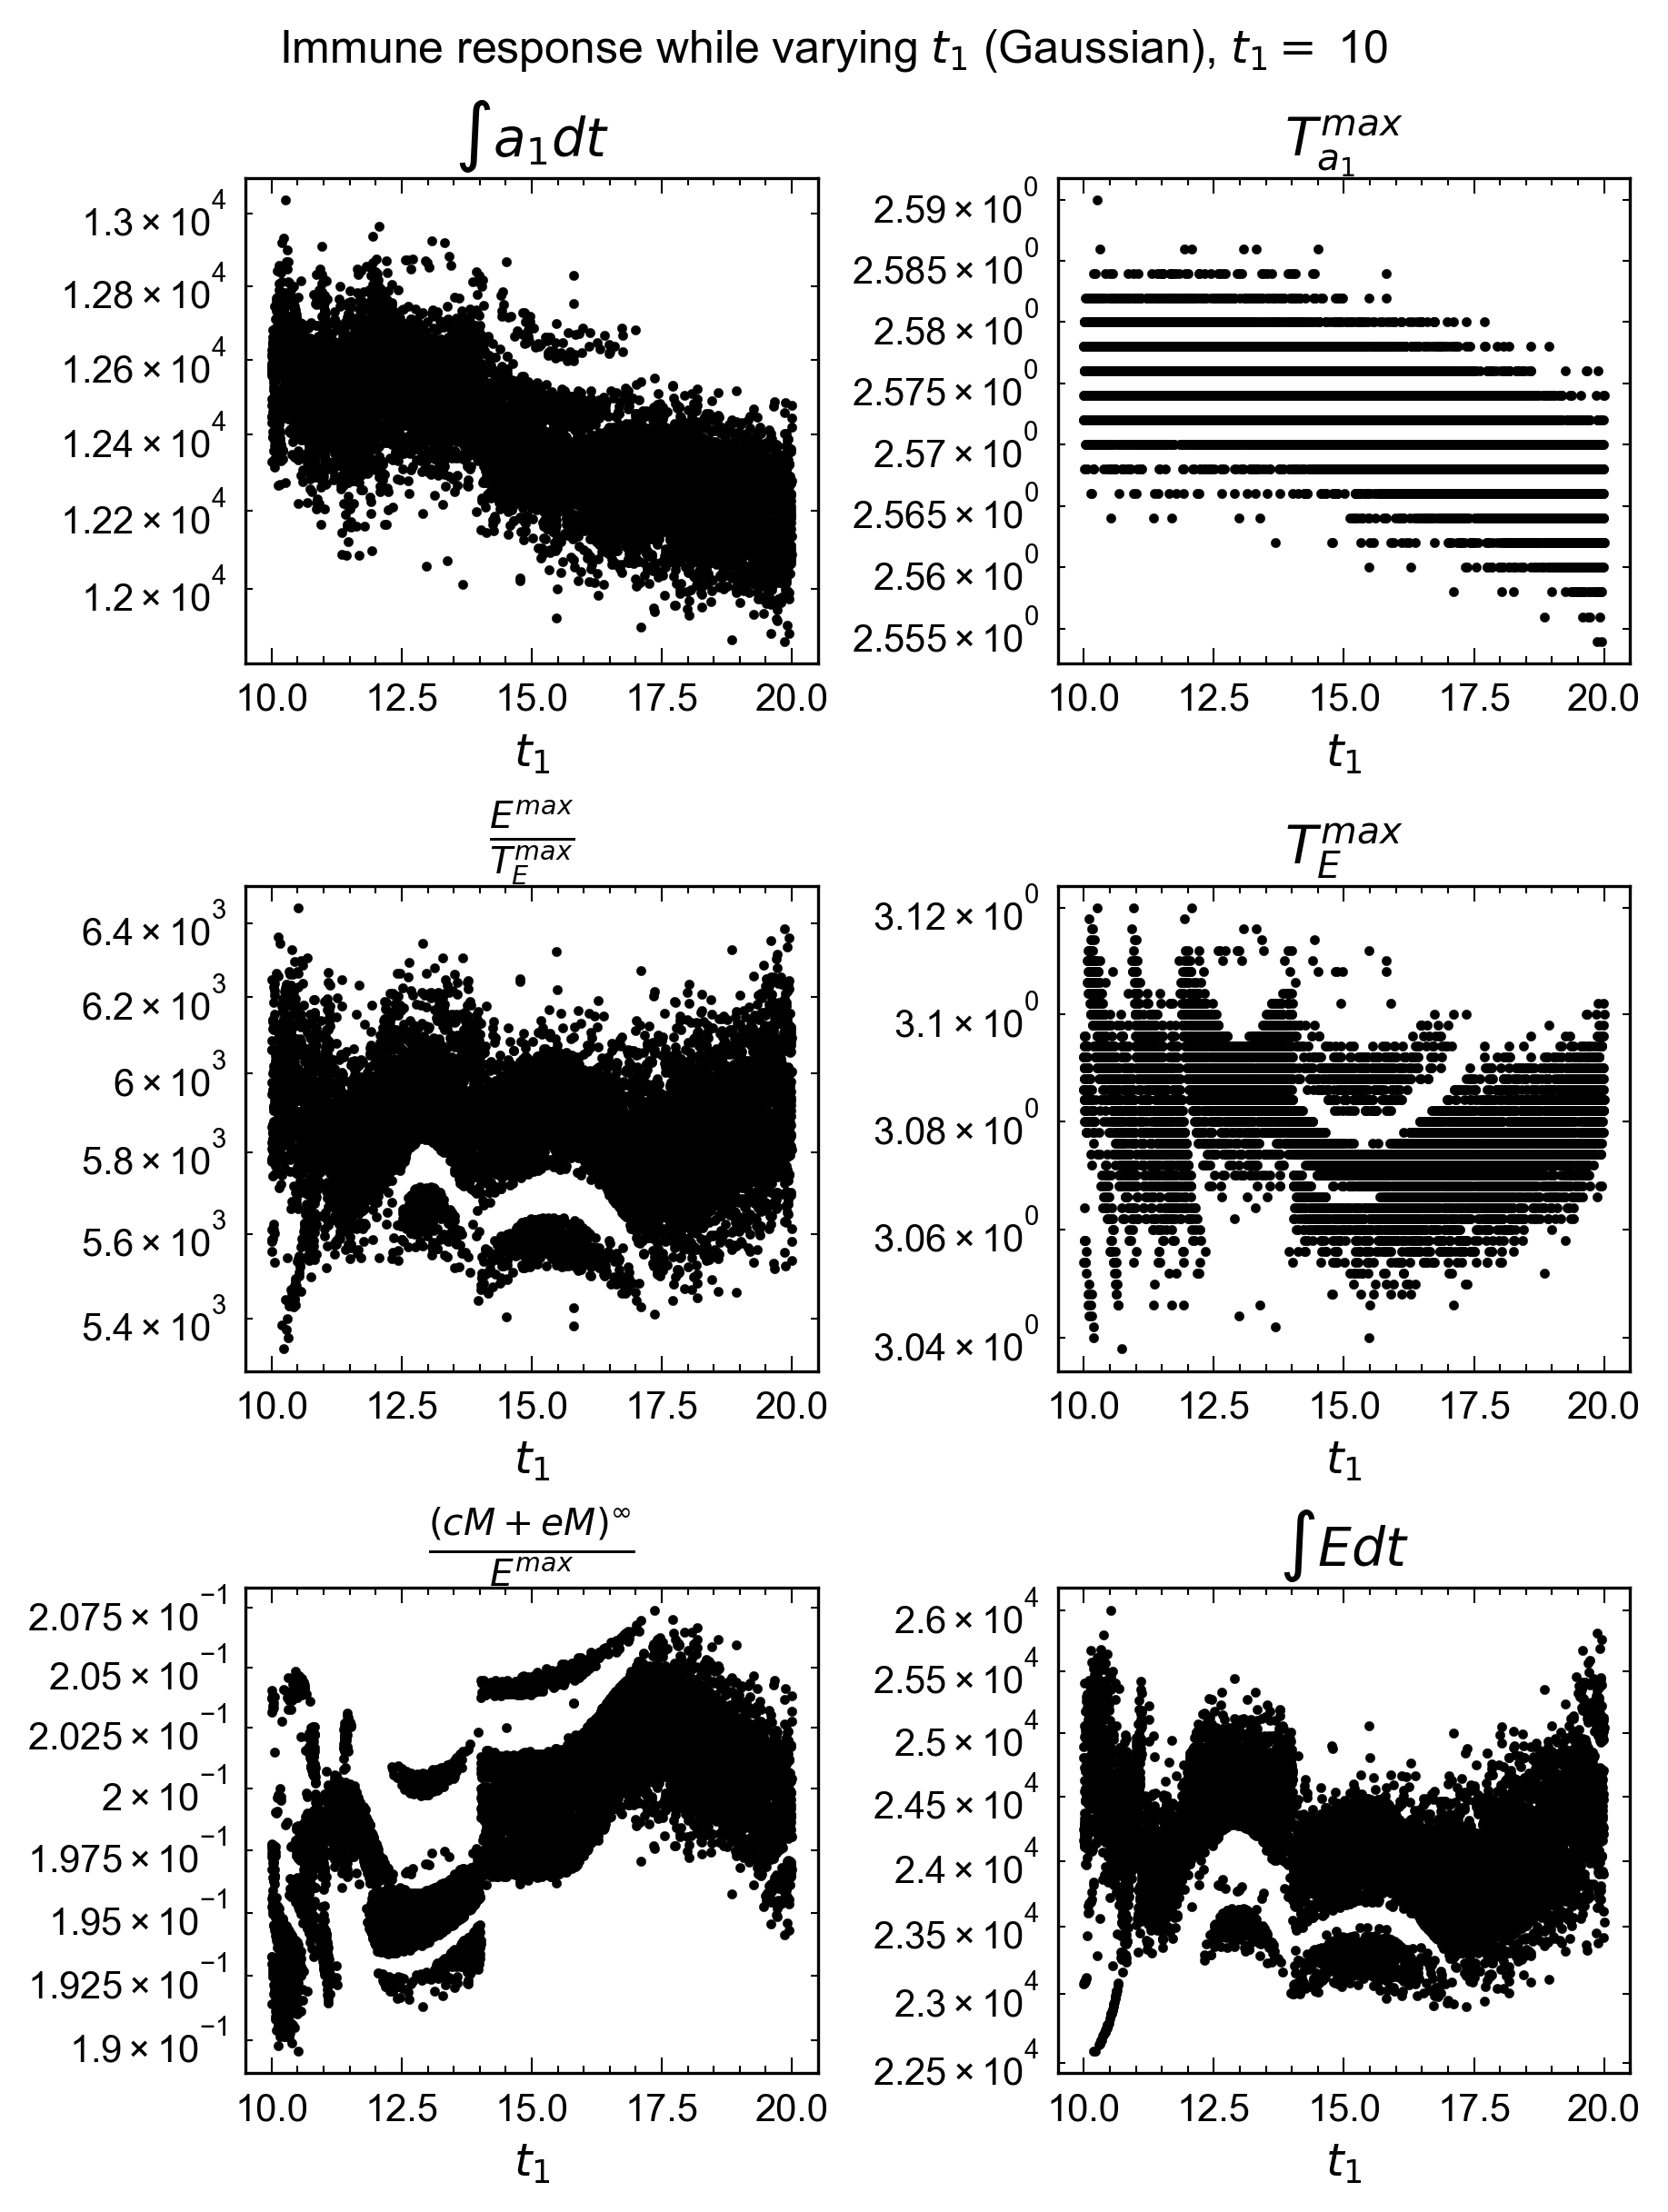

In [14]:
# Plot trajectories for t1
fig_t1, axs = plt.subplots(3, 2, dpi = 150, constrained_layout=True, figsize=(6,8))
i = 4
for ax, val in zip(axs.flat,stat_names[i:]):

    cs = ax.plot(run_data_t1[:,2],run_data_t1[:,i],'k.')
    ax.set_title(val)
    ax.set(xlabel=r'$t_1$')
    ax.semilogy()
    
    i += 1

fig_t1.suptitle(r'Immune response while varying $t_1$ (Gaussian), $t_1=$ '+str(t1))
plt.show()
fig_t1.savefig('plot-response-varying-t1-gauss-t1-'+str(t1)+'.png', dpi=150)

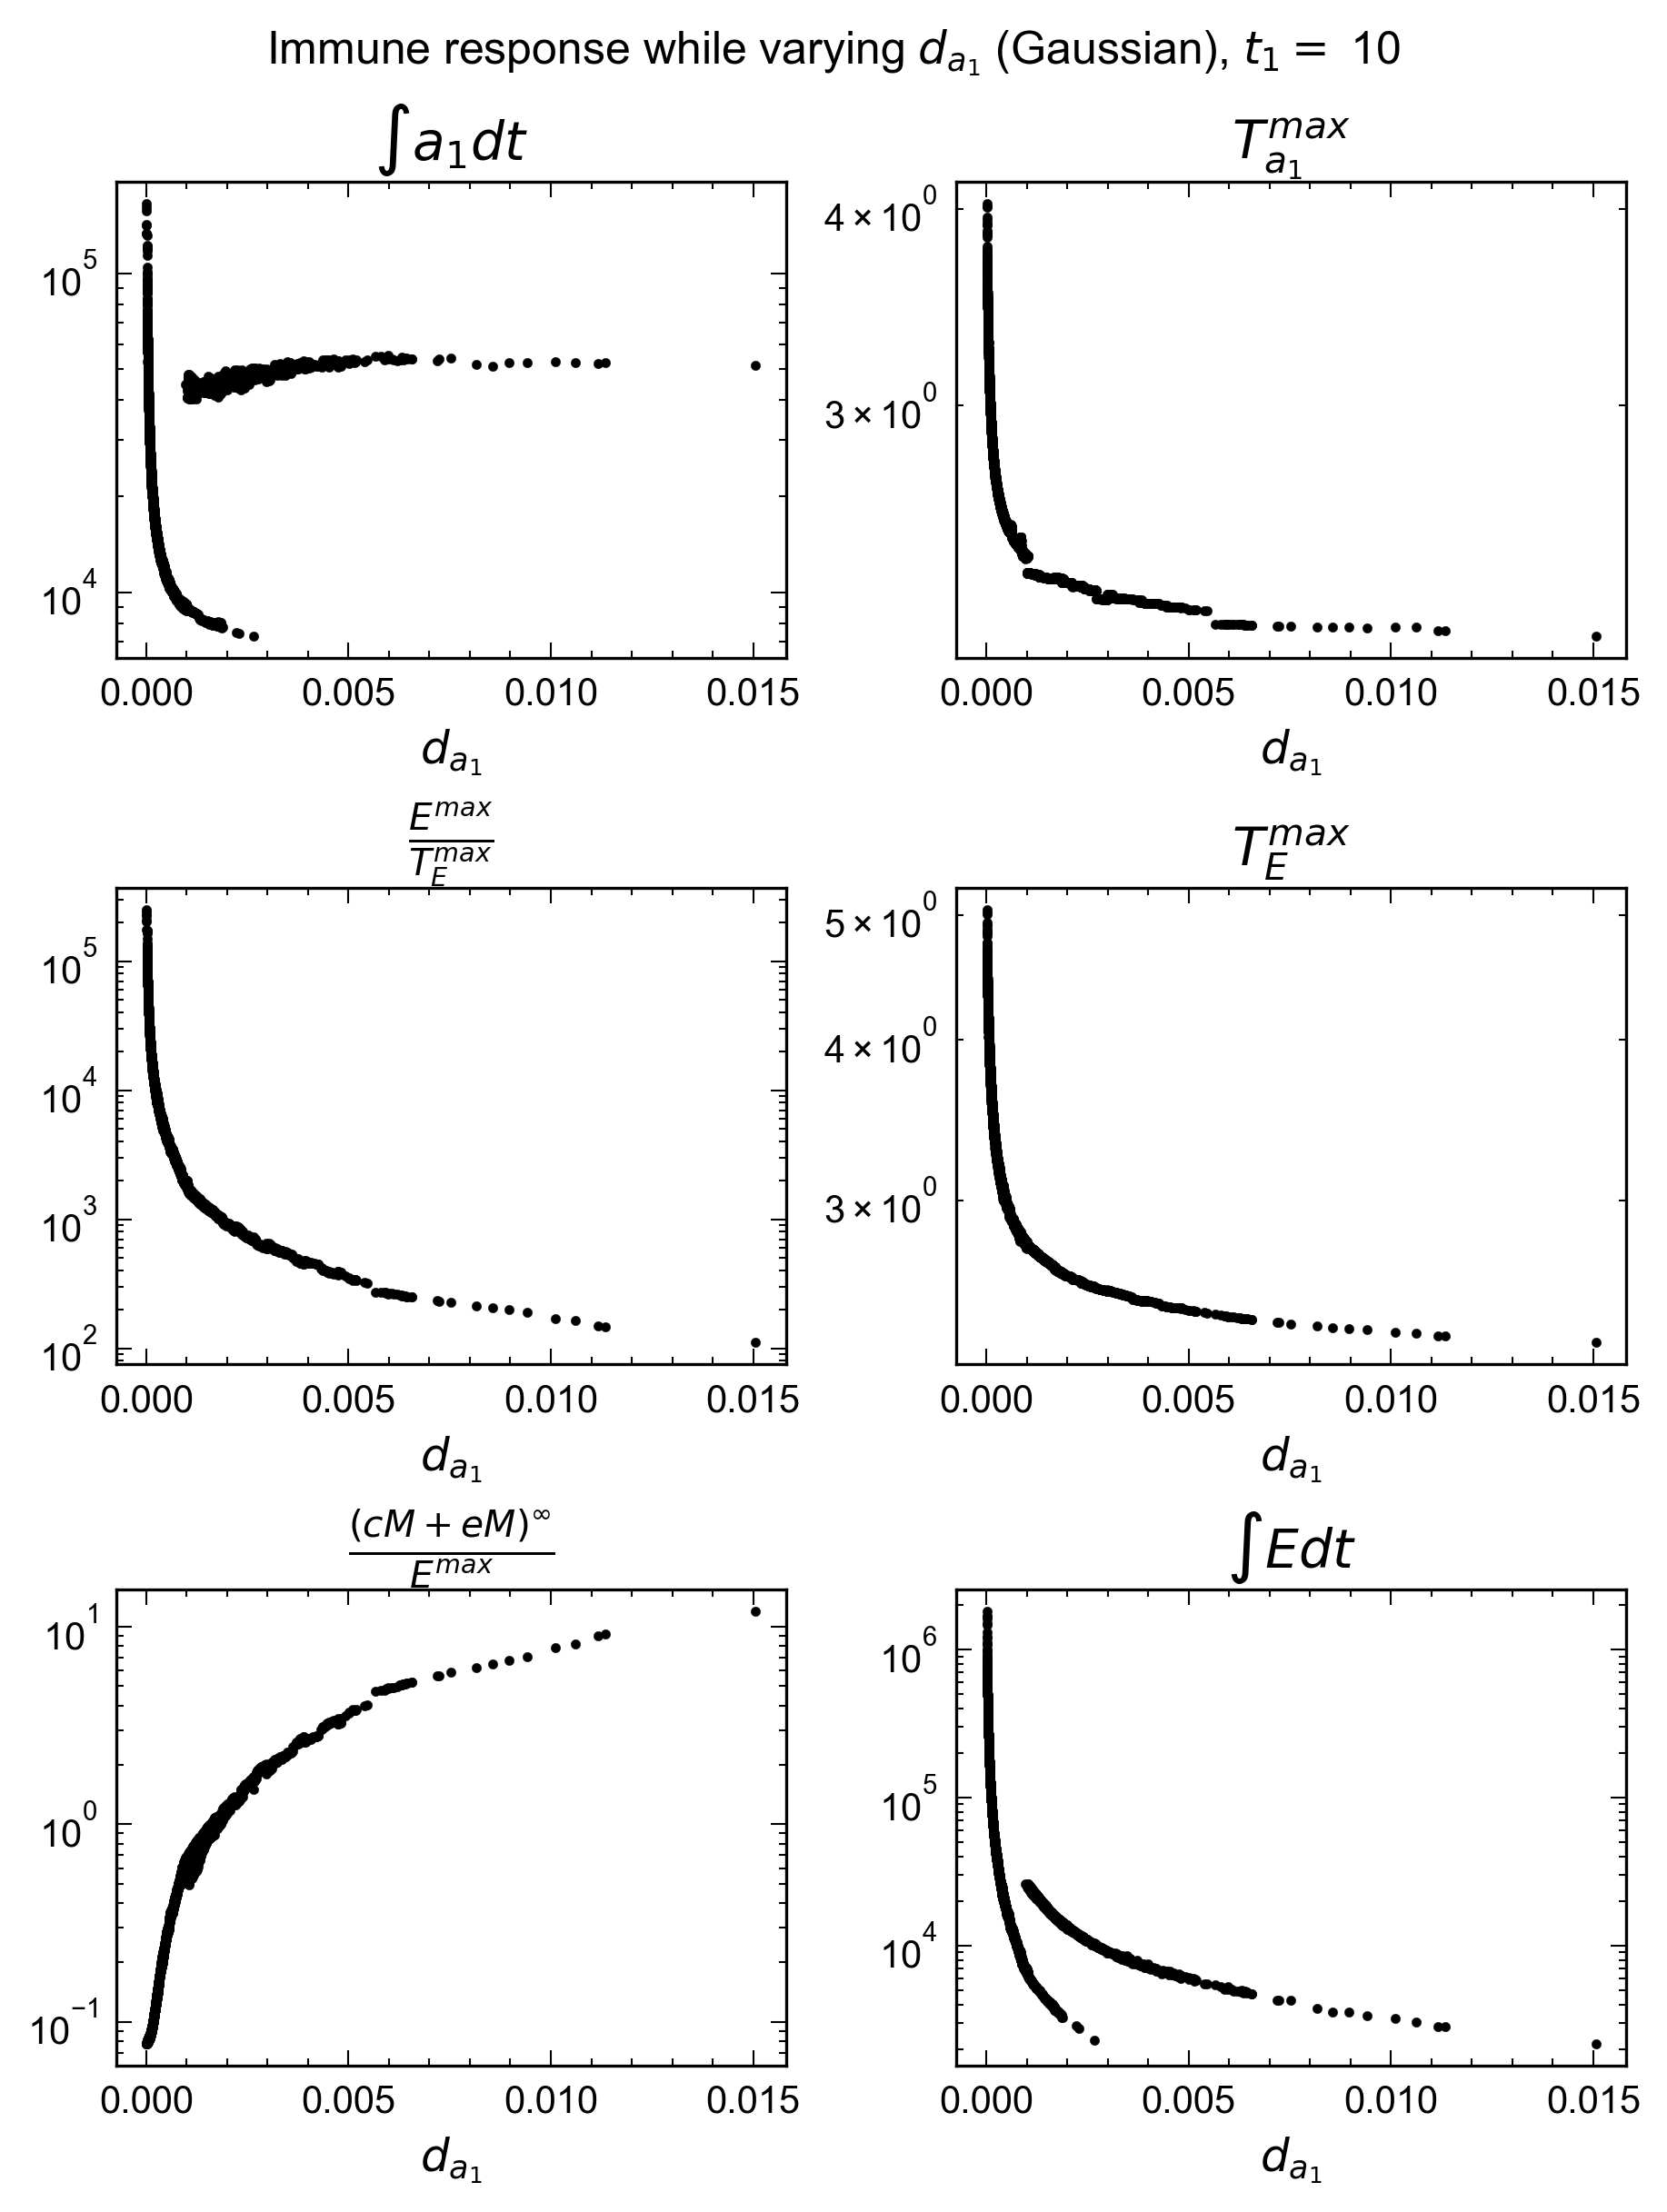

In [15]:
# Plot trajectories for d_a1
fig_t1, axs = plt.subplots(3, 2, dpi = 150, constrained_layout=True, figsize=(6,8))
i = 4
for ax, val in zip(axs.flat,stat_names[i:]):

    cs = ax.plot(run_data_d_a1[:,3],run_data_d_a1[:,i],'k.')
    ax.set_title(val)
    ax.set(xlabel=r'$d_{a_1}$')
    ax.semilogy()
    
    i += 1

fig_t1.suptitle(r'Immune response while varying $d_{a_1}$ (Gaussian), $t_1=$ '+str(t1))
plt.show()
fig_t1.savefig('plot-response-varying-d_a1-gauss-t1-'+str(t1)+'.png', dpi=150)

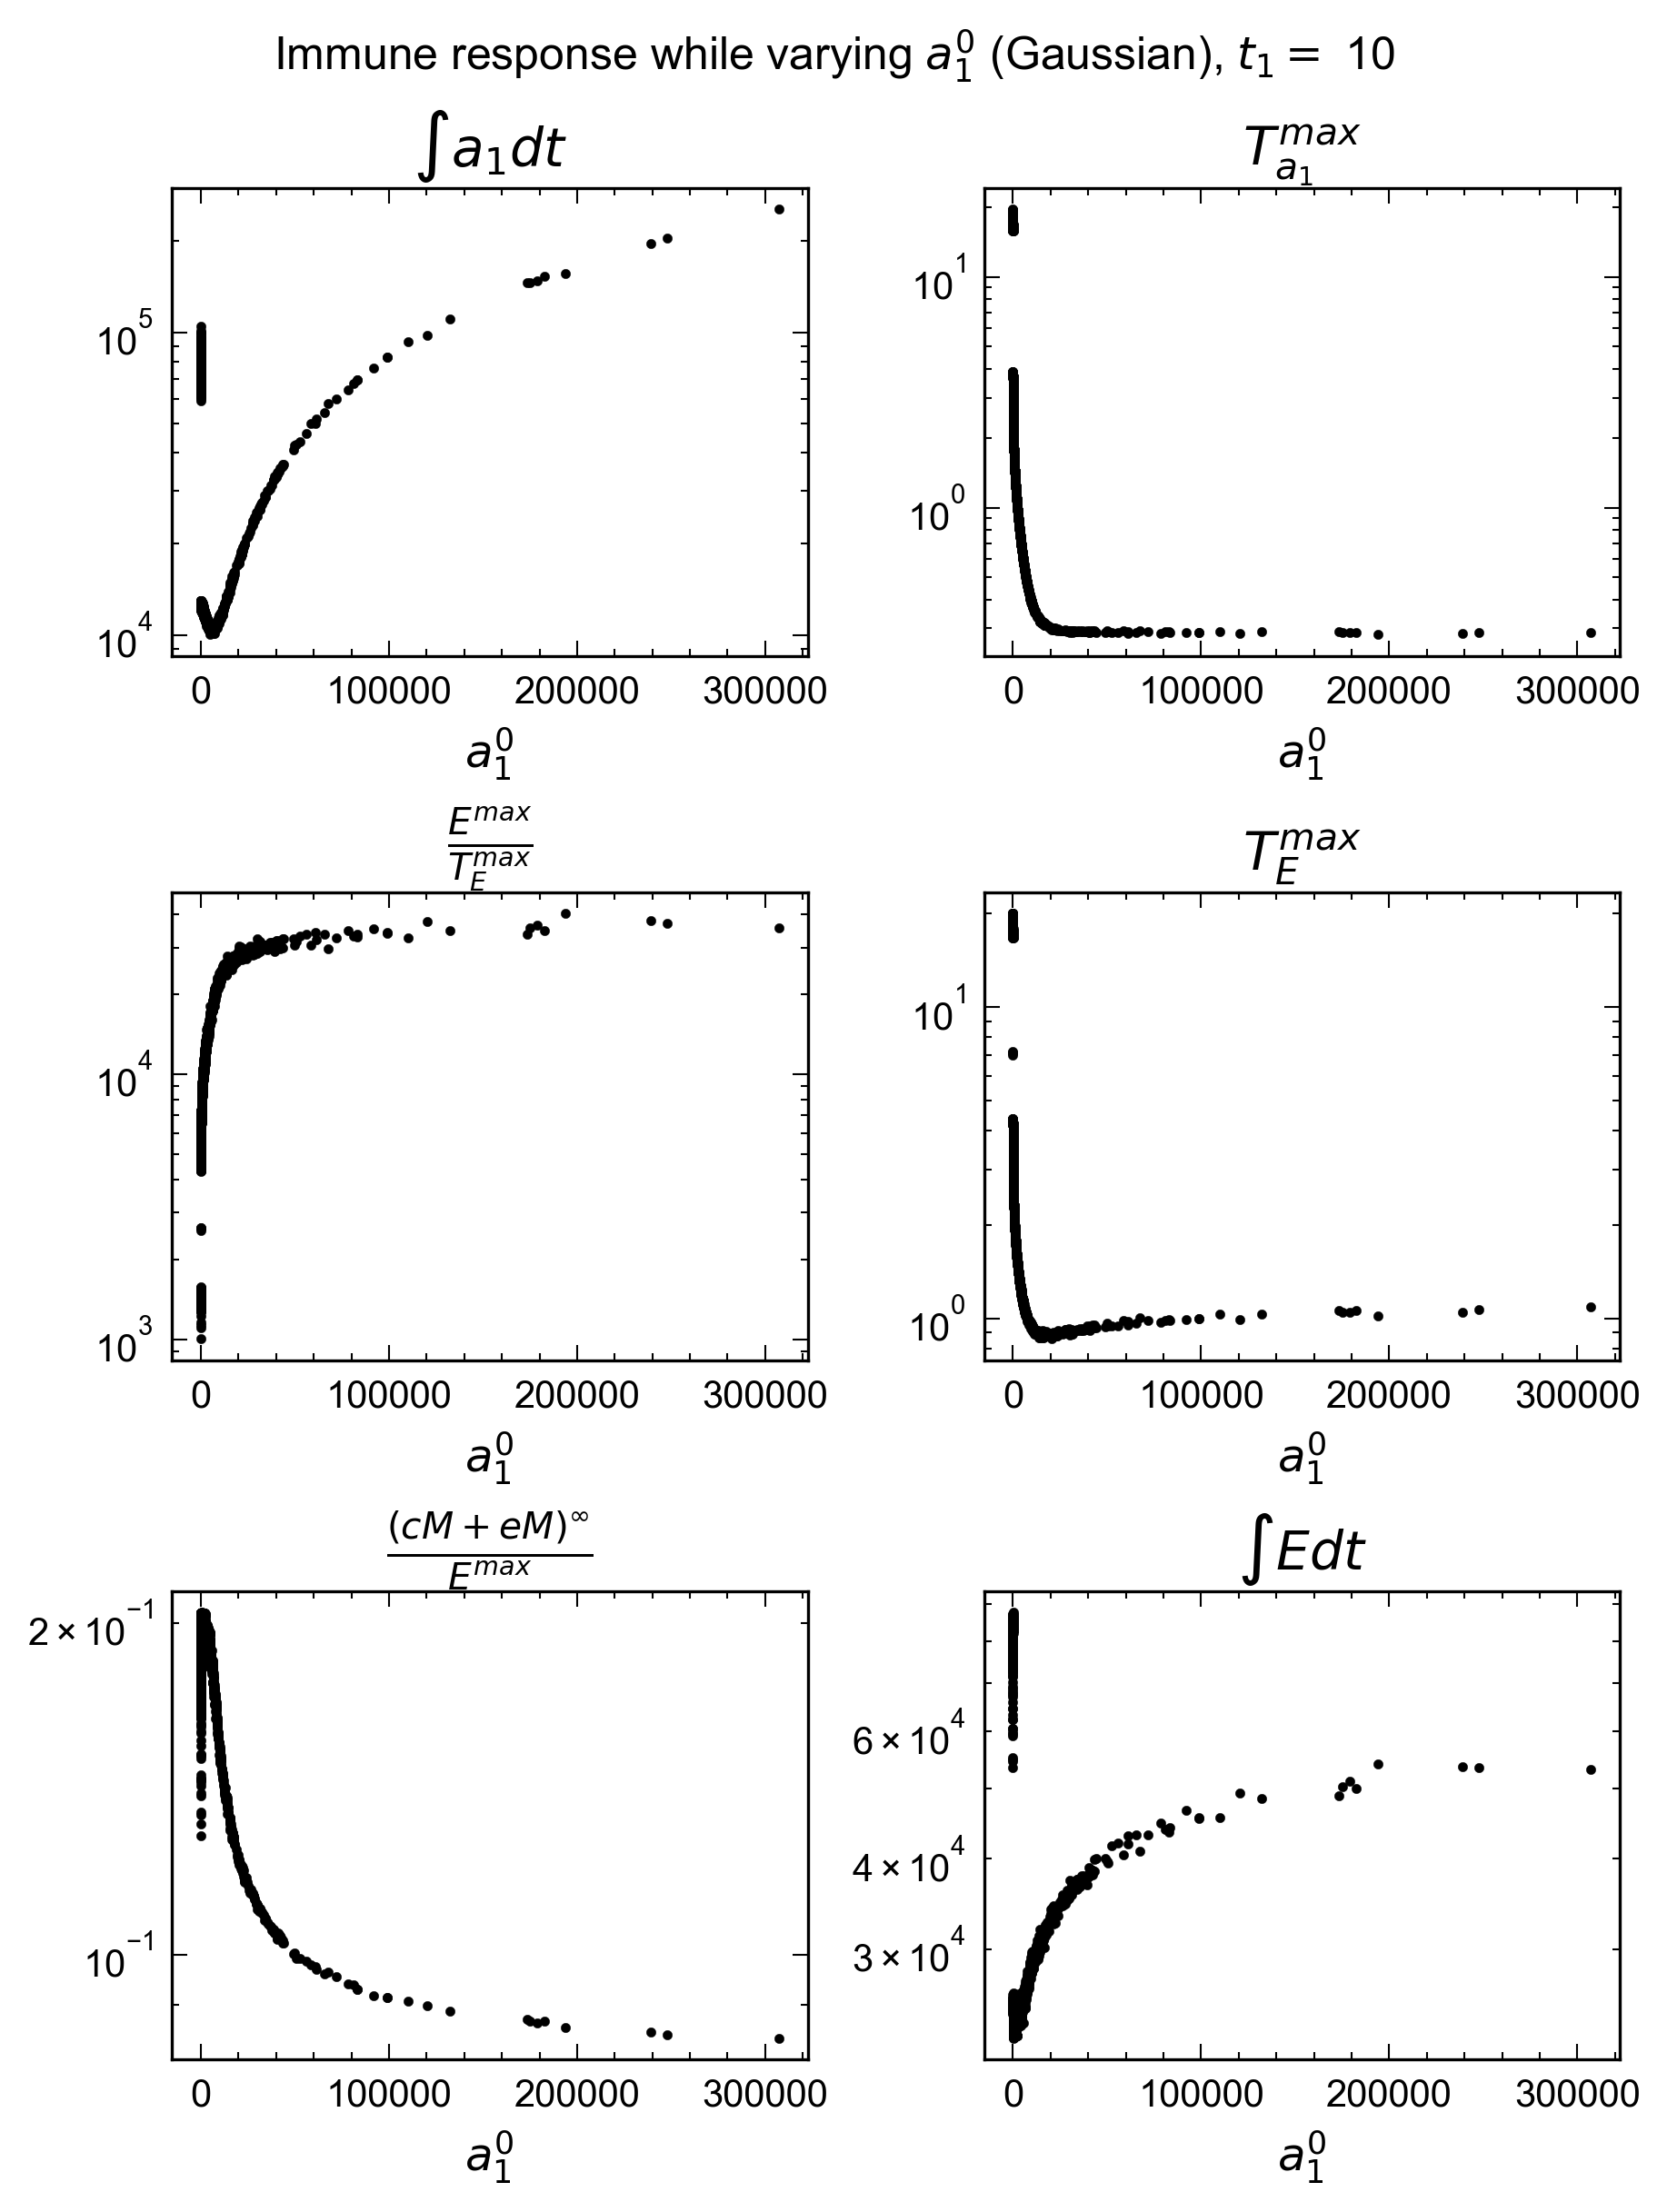

In [16]:
# Plot trajectories for T_a1
fig_t1, axs = plt.subplots(3, 2, dpi = 150, constrained_layout=True, figsize=(6,8))
i = 4
for ax, val in zip(axs.flat,stat_names[i:]):

    cs = ax.plot(run_data_a1_0[:,0],run_data_a1_0[:,i],'k.')
    ax.set_title(val)
    ax.set(xlabel=r'$a_{1}^0$')
    ax.semilogy()
        
    i += 1

fig_t1.suptitle(r'Immune response while varying $a_1^0$ (Gaussian), $t_1=$ '+str(t1))
plt.show()
fig_t1.savefig('plot-response-varying-a1_0-gauss-t1-'+str(t1)+'.png', dpi=150)